In [1]:

from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [3]:
from place_tools import (
    ancient_keyword_search,
    journey_description_search,
    journey_route_search,
    search_ancient_places,
    search_ancient_with_modern,
    search_modern_places,
    search_modern_with_ancient,
)

# create_agent 가 내부적으로 llm.bind_tools + tool loop 를 처리하므로
# 기존 llm_with_tools / tool_node 는 만들지 않는다.
tool_list = [
    ancient_keyword_search,
    search_ancient_places,
    search_modern_places,
    search_ancient_with_modern,
    search_modern_with_ancient,
    journey_route_search,
    journey_description_search,
]


In [4]:
from langgraph.graph import MessagesState

class AgentState(MessagesState):
    query: str
    answer: str
    # 이름 → [place_id, ...]. 여러 record가 같은 이름을 가질 수 있어서 리스트.
    # 프론트는 id 첫 글자로 stereo 판별 (a... = ancient, m... = modern).
    place_id_map: dict[str, list[str]]
    recommended_questions: list[str]


In [5]:
from langgraph.graph import StateGraph
graph_builder = StateGraph(AgentState)

In [6]:
from pathlib import Path
from langchain.agents import create_agent


# PRD가 시스템 프롬프트의 canonical source.
# 노트북은 agents/places/에서 실행된다고 가정 → 프로젝트 루트는 ../..
_PRD_PATH = Path("../../docs/agent-prd.md").resolve()
PLACE_AGENT_SYSTEM = _PRD_PATH.read_text(encoding="utf-8")


# create_agent 가 tool 호출 loop를 내부에서 처리 (LangGraph 최적화된 ReAct 구현).
# 외부 그래프에서는 place_agent 노드 하나로 tool 반복까지 다 끝난다.
_place_agent_runnable = create_agent(
    model=llm,
    tools=tool_list,
    system_prompt=PLACE_AGENT_SYSTEM,
)


def place_agent(state: AgentState):
    """place_agent 노드.

    내부적으로 tool 호출 반복까지 완료된 뒤 최종 AIMessage 를 포함한
    전체 messages 를 반환한다. add_messages reducer 로의 중복 append 를
    피하기 위해 입력 이후의 delta 만 return.
    """
    initial_count = len(state["messages"])
    result = _place_agent_runnable.invoke({"messages": state["messages"]})
    new_messages = result["messages"][initial_count:]
    print(f">> [place_agent] 새로 추가된 메시지 {len(new_messages)}개 (tool loop 완료)")
    return {"messages": new_messages}


In [7]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

bible_general_agent_prompt = PromptTemplate.from_template(
    """성경 질문 응답 도우미.
규칙:
- 한국어면 반드시 존댓말(-습니다체). 반말·평서체(-다) 금지.
- 3~5문장 이내, 성경 본문·인물·사건·신학에 한정.
- 확신 없으면 "성경에서 명확히 다루지 않는다".
- 서두·맺음말·이모지 금지.

질문: {query}
"""
)

mini_llm = ChatOpenAI(model="gpt-4o-mini", max_tokens=400, temperature=0.2)
bible_general_agent_chain = bible_general_agent_prompt | mini_llm | StrOutputParser()

def bible_general_agent(state: AgentState):
    return {'answer': bible_general_agent_chain.invoke({"query": state['query']})}

In [8]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI


class NonBibleResponse(BaseModel):
    answer: str = Field(description="성경 무관하다는 정중한 안내. 1~2문장. 사용자 질문 언어와 동일.")
    recommended_questions: list[str] = Field(
        default_factory=list,
        max_length=3,
        description="대체 질문 3개. 원 질문 맥락과 연결지어 성경 지리·지명 예시 질문 형태로.",
    )


non_bible_reject_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """사용자 질문이 성경 도메인 밖. 두 필드 채워 반환:
- answer: 1~2문장, "성경 무관해 답변 어렵다"는 정중한 안내.
- recommended_questions: 성경 지리·지명 예시 질문 3개, 원 질문 맥락과 연결 가능하면 그 쪽으로.
언어는 사용자 질문 언어(한국어/영어)와 동일. 이모지·부연 금지."""
    ),
    ("user", "질문: {query}"),
])

nano_llm = ChatOpenAI(model="gpt-4.1-nano", max_tokens=300, temperature=0.3)
non_bible_reject_chain = non_bible_reject_prompt | nano_llm.with_structured_output(NonBibleResponse)


def non_bible_reject(state: AgentState):
    result = non_bible_reject_chain.invoke({'query': state['query']})
    return {'answer': result.answer, 'recommended_questions': result.recommended_questions}

In [9]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

class Route(BaseModel):
    target: Literal['place_agent','bible_general_agent','non_bible_reject'] = Field(description='The target for the query to answer')

router_system_prompt = """사용자 질문을 세 target 중 하나로 분류:
- `place_agent`: 성경 지명·지리·여정·현대 위치 관계
- `bible_general_agent`: 성경 인물·교리·구절 해석·개념 (장소 중심 아님)
- `non_bible_reject`: 성경 무관

규칙:
- 성경 지명·여정 명시 → place_agent
- 성경 개념·인물·구절인데 장소 초점 아님 → bible_general_agent
- 성경 요소 없음 → non_bible_reject
- 애매하면 성경 쪽, 장소 조금이라도 관련되면 place_agent

**context 활용**: 현재 질문이 지시대명사(그곳/거기/그때 등)나 후속 표현(그럼~/이후에 등)을 포함하고 [context]가 성경 지리면 place_agent, 성경 인물·교리면 bible_general_agent 로 유지. context 가 "(없음)"이고 현재 질문에 성경 신호 없으면 non_bible_reject. 이전과 무관한 새 주제면 현재 질문 기준.
"""


router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '[context]\n{context}\n\n[현재 질문]\n{query}'),
])

structured_router_llm = small_llm.with_structured_output(Route)


def _build_router_context(messages: list) -> str:
    if len(messages) <= 1:
        return "(없음)"
    lines: list[str] = []
    for msg in messages[:-1]:
        if isinstance(msg, SystemMessage):
            lines.append(msg.content)
        elif isinstance(msg, HumanMessage):
            lines.append(f"user: {msg.content[:300]}")
        elif isinstance(msg, AIMessage):
            lines.append(f"assistant: {msg.content[:300]}")
    if not lines:
        return "(없음)"
    return "\n".join(lines[-5:])


def router(state: AgentState):
    query = state['query']
    context = _build_router_context(state.get('messages') or [])
    route = (router_prompt | structured_router_llm).invoke({'query': query, 'context': context})
    print(f'route.target == {route.target}')
    return route.target

In [10]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.messages import ToolMessage


class RelevanceCheck(BaseModel):
    is_relevant: bool = Field(
        description="답변이 질문에 실제로 부합하고 사실적으로 문제가 없으면 true, 그렇지 않으면 false"
    )
    reason: str = Field(
        default="",
        description="판단 근거를 한 문장 이내로 짧게 기술"
    )


relevance_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        당신은 답변이 사용자 질문과 도구 검색 결과에 얼마나 잘 부합하는지
        평가하는 판정자입니다.

        판단 기준:
        - 답변이 질문의 요지를 정면으로 다루는가.
        - 도구 결과가 있으면 답변이 그 결과에 근거하는가.
        - 서로 다른 장소를 하나로 합치거나, 도구 결과에 없는 place_id/좌표/현대
          지명을 만들어내지 않았는가.
        - 명백한 사실 오류나 회피성 답변이 아닌가.

        **아래 조건 중 하나라도 해당하면 반드시 is_relevant = false:**
        1. 도구 결과가 전부 비어있고([] 또는 빈 문자열), 답변에
           "정보가 없다", "명확한 지명이 제공되지 않았", "구체적 자료가 없",
           "다른 자료를 참고", "명시되지 않았", "제공되지 않았"
           같은 정보 부족을 인정하는 표현이 있는 경우.
           → rewrite 노드가 LLM 사전 지식으로 더 나은 답변을 만들어야 함.
        2. 답변이 질문의 핵심(지명·인물·사건)을 다루지 못하고 회피.
        3. 답변이 비어있거나 지나치게 모호.

        **예외 - 다음은 is_relevant = true 허용:**
        - 질문 자체가 성경 밖 초월적/추상적 주제(예: "천국은 어디?")이고
          답변이 성경적 관점에서 적절히 짚어준 경우.
        - 도구 결과가 존재하고 답변이 그 결과와 일관되게 작성된 경우.

        reason에는 판단 근거 한 문장만 짧게.
        """
    ),
    (
        "user",
        """
        질문:
        {query}

        도구 검색 결과:
        {tool_results}

        최종 답변:
        {answer}
        """
    ),
])

judge_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
relevance_chain = relevance_prompt | judge_llm.with_structured_output(RelevanceCheck)


def evaluate_answer(state: AgentState) -> Literal["rewrite", "format"]:
    tool_results = [
        message.content
        for message in state["messages"]
        if isinstance(message, ToolMessage)
    ]

    check = relevance_chain.invoke({
        "query": state["query"],
        "answer": state["messages"][-1].content,
        "tool_results": tool_results,
    })

    print(f">> [evaluate_answer] is_relevant={check.is_relevant} | reason={check.reason}")
    return "rewrite" if not check.is_relevant else "format"

In [11]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI


rewrite_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """성경 지리·지명 전문가. DB 결과 부족해 사전 지식만으로 답.
- 한국어면 반드시 존댓말(-습니다체). 반말·평서체(-다) 금지.
- 성경 본문·전통·널리 알려진 학설 수준.
- 확실한 사실은 단정, 이견 있으면 "학자들 사이 의견이 갈리지만 흔히…" 첨언.
- 좌표·place_id·확신 없는 수치 금지.
- 성경 미명시는 "성경에서 명확히 다루지 않음".
- 3~5문장. 사과·메타·이모지 금지."""
    ),
    ("user", "질문: {query}"),
])

rewrite_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2, max_tokens=500)
rewrite_chain = rewrite_prompt | rewrite_llm | StrOutputParser()


def rewrite(state: AgentState):
    print(">> [rewrite] 진입")
    return {"answer": rewrite_chain.invoke({"query": state["query"]})}

In [12]:
import json
import re
from langchain_core.messages import ToolMessage


# DB 동명이인 구분용 접미 숫자(예: "안디옥1", "안디옥 2", "Antioch3") 를
# 벗겨 base name 하나로 place_id 후보들을 버킷팅한다. 이렇게 하면
# (a) 고대·현대가 같은 이름이거나 (b) DB 가 접미 숫자로 동명을 구분해
# 저장한 경우 모두 하나의 key 로 모든 후보 id 가 모인다.
_TRAILING_DIGITS_RE = re.compile(r"\s*\d+$")


def _normalize_place_name(name: str) -> str:
    stripped = _TRAILING_DIGITS_RE.sub("", name).rstrip()
    return stripped or name


def _extract_place_refs(tool_message_content: str) -> dict[str, list[str]]:
    """도구 결과 JSON 에서 {이름(정규화): [place_id, ...]} 매핑을 뽑는다.

    - top-level record + nested `modern_places` / `ancient_places` 재귀 순회.
    - 같은 base name 에 여러 place_id 가 붙을 수 있음
      (고대·현대 동명, 접미 숫자로 구분된 동명이인 등).
    - 프론트는 id 첫 글자로 stereo 판별 (a... = ancient, m... = modern).
    """
    refs: dict[str, list[str]] = {}

    def _add(name: str, pid: str) -> None:
        key = _normalize_place_name(name)
        bucket = refs.setdefault(key, [])
        if pid not in bucket:
            bucket.append(pid)

    def _walk(item):
        if not isinstance(item, dict):
            return
        pid = item.get("place_id")
        if pid:
            for key in ("name_ko", "name_en"):
                name = item.get(key)
                if name:
                    _add(name, pid)
        for nested_key in ("modern_places", "ancient_places"):
            for nested_item in item.get(nested_key) or []:
                _walk(nested_item)

    try:
        data = json.loads(tool_message_content)
    except (TypeError, ValueError):
        return refs
    if not isinstance(data, list):
        return refs
    for item in data:
        _walk(item)
    return refs


def _merge_refs(dst: dict[str, list[str]], src: dict[str, list[str]]) -> None:
    """여러 tool 결과 refs 를 dst 에 병합. 중복 제거."""
    for name, ids in src.items():
        bucket = dst.setdefault(name, [])
        for pid in ids:
            if pid not in bucket:
                bucket.append(pid)


# 답변 말미에 LLM 이 place_id_map 을 markdown 으로 다시 나열하는 경우
# (PRD Rule 11 위반) 를 방어적으로 잘라낸다. 프롬프트가 실패해도 프론트
# 로는 절대 나가지 않게 하는 최후 방어선.
_PLACE_ID_MAP_BLOCK_RE = re.compile(
    r"\n+\s*\**\s*place[_ ]?id[_ ]?map\s*\**\s*:.*\Z",
    re.IGNORECASE | re.DOTALL,
)


def _strip_place_id_map_block(text: str) -> str:
    return _PLACE_ID_MAP_BLOCK_RE.sub("", text).rstrip()


def format(state: AgentState):
    messages = state["messages"]
    # rewrite에서 answer가 이미 세팅됐으면 그것 보존, 아니면 마지막 메시지 사용
    answer_text = state.get("answer") or messages[-1].content
    answer_text = _strip_place_id_map_block(answer_text)

    tool_message_count = sum(1 for m in messages if isinstance(m, ToolMessage))
    print(f">> [format] 진입 (전체 메시지 {len(messages)}개, ToolMessage {tool_message_count}개)")

    place_id_map: dict[str, list[str]] = {}
    for msg in messages:
        if isinstance(msg, ToolMessage):
            _merge_refs(place_id_map, _extract_place_refs(msg.content))

    total_ids = sum(len(v) for v in place_id_map.values())
    print(f">> [format] place_id_map {len(place_id_map)}개 이름 / 총 {total_ids}개 id, 답변 {len(answer_text)}자")

    return {
        "answer": answer_text,
        "place_id_map": place_id_map,
    }


In [13]:
# tools 노드 제거됨 - create_agent 가 내부적으로 처리
graph_builder.add_node('place_agent', place_agent)
graph_builder.add_node('bible_general_agent', bible_general_agent)
graph_builder.add_node('non_bible_reject', non_bible_reject)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('format', format)


In [14]:
from langgraph.graph import START, END
from typing import Literal


def route_from_agent(state: AgentState) -> Literal['rewrite', 'format']:
    """place_agent 이후 다음 노드 결정.

    tool loop 는 create_agent 가 내부에서 이미 끝냈으므로 여기선
    답변 평가 결과에 따라 rewrite / format 만 분기.
    """
    decision = evaluate_answer(state)
    print(f">> [route_from_agent] → {decision}")
    return decision


# START → router → 세 도메인 중 하나
graph_builder.add_conditional_edges(START, router, {
    'place_agent': 'place_agent',
    'bible_general_agent': 'bible_general_agent',
    'non_bible_reject': 'non_bible_reject',
})

# place_agent 결과 평가 → rewrite / format
graph_builder.add_conditional_edges('place_agent', route_from_agent, {
    'rewrite': 'rewrite',
    'format': 'format',
})

# rewrite 도 format 을 거쳐서 place_id_map 을 채우고 종료
graph_builder.add_edge('rewrite', 'format')

# 종료 분기
graph_builder.add_edge('bible_general_agent', END)
graph_builder.add_edge('non_bible_reject', END)
graph_builder.add_edge('format', END)


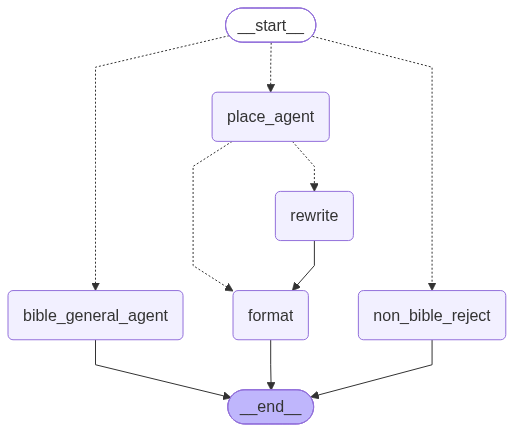

In [15]:
from IPython.display import Image, display
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
query='바울의 2차전도 여정을 알려줘'

In [17]:
from langchain_core.messages import HumanMessage

initial_state = {
    "query": query,
    "messages": [HumanMessage(content=query)],
}

print(f"[QUERY] {query}")
print("=" * 70)

for chunk in graph.stream(initial_state, stream_mode="updates"):
    for node_name, update in chunk.items():
        print(f"\n{'=' * 70}")
        print(f"NODE: {node_name}")
        print("-" * 70)

        if not update:
            print("(no state update)")
            continue

        for key, value in update.items():
            if key == "messages":
                for message in value:
                    message.pretty_print()
            elif key == "answer":
                print(f"\n[answer]\n{value}")
            elif key == "place_id_map":
                total = sum(len(v) for v in value.values())
                print(f"\n[place_id_map]  이름 {len(value)}개 / 총 id {total}개")
                for name, ids in value.items():
                    if len(ids) == 1:
                        print(f"  {name}  →  {ids[0]}")
                    else:
                        print(f"  {name}  →  {ids}  ⚠ 다중 (id 첫 글자로 구분: a=ancient, m=modern)")
            elif key == "recommended_questions":
                print(f"\n[recommended_questions]  ({len(value)}개)")
                for i, q in enumerate(value, 1):
                    print(f"  {i}. {q}")
            else:
                print(f"[{key}] {value}")

[QUERY] 바울의 2차전도 여정을 알려줘
route.target == place_agent
>> [place_agent] 새로 추가된 메시지 6개 (tool loop 완료)
>> [evaluate_answer] is_relevant=True | reason=답변이 바울의 2차 전도 여정의 주요 장소와 활동을 구체적으로 설명하고 있으며, 도구 검색 결과와 일치한다.
>> [route_from_agent] → format

NODE: place_agent
----------------------------------------------------------------------
================================== Ai Message ==================================
Tool Calls:
  journey_route_search (call_IS3NIuu0tzilELQEbLC09oFZ)
 Call ID: call_IS3NIuu0tzilELQEbLC09oFZ
  Args:
    query: 바울의 2차전도 여정
  journey_description_search (call_NTPVzKRUtpsF1WeyDeKFAP3f)
 Call ID: call_NTPVzKRUtpsF1WeyDeKFAP3f
  Args:
    query: 바울의 2차전도 여정
================================= Tool Message =================================
Name: journey_route_search

["Antioch", "Syria", "Cilicia", "Derbe", "Lystra", "Iconium", "Troas", "Philippi", "Thessalonica", "Berea"]
================================= Tool Message =================================
Name: journey_descripti

## 멀티턴 채팅 (run_turn) 테스트

`agents/places/chat.py` 의 `run_turn` 으로 멀티턴을 굴린다.
클라가 하는 그대로:
- `summary`, `messages` 를 로컬에 유지
- 매 턴 요청에 실어 보냄
- 매 턴 응답의 `summary`, `messages` 로 로컬 상태 **통째 교체**

`THRESHOLD = 10` 이므로 6번째 턴에서 12개 → 요약 트리거 & `messages = []` 리셋.

In [18]:
# from chat import THRESHOLD, ChatMessage, run_turn

# # 클라이언트가 유지하는 로컬 상태
# summary: str | None = None
# messages: list[ChatMessage] = []

# turns = [
#     "베들레헴이 어디야?",
#     "예수님이 그곳에서 태어났다고 들었는데 성경 어디에 나와?",
#     "예수님의 공생애 사역은 어디서 시작됐어?",
#     "그럼 그 이후 어디로 이동하셨어?",
# ]

# for i, q in enumerate(turns, 1):
#     print(f"\n{'=' * 70}")
#     print(f"[턴 {i}] {q}")
#     print(f"  요청에 실은 상태: summary={'있음' if summary else 'None'} / messages {len(messages)}개")
#     print("=" * 70)

#     result = run_turn(query=q, summary=summary, messages=messages, graph=graph)

#     print(f"\n[answer]\n{result.answer}")

#     if result.place_id_map:
#         print(f"\n[place_id_map] {len(result.place_id_map)}개 이름")
#         for name, ids in result.place_id_map.items():
#             print(f"  {name}  →  {ids}")

#     if result.recommended_questions:
#         print(f"\n[recommended_questions]")
#         for j, rq in enumerate(result.recommended_questions, 1):
#             print(f"  {j}. {rq}")

#     print(f"\n[응답으로 받은 새 상태]")
#     if result.summary:
#         preview = result.summary[:250] + ("..." if len(result.summary) > 250 else "")
#         print(f"  summary ({len(result.summary)}자):\n    {preview}")
#     else:
#         print("  summary: None")
#     print(f"  messages: {len(result.messages)}개")

#     # 클라가 하듯이 통째로 교체
#     summary = result.summary
#     messages = result.messages